In [63]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [64]:
import pandas as pd

# 1. Load the Wage/Demand Forecast Dataset
df = pd.read_csv("../../datasets/wage_demand_forecast_data.csv")

print("--- Wage & Demand Forecast Data ---")
print(f"Dataset Shape: {df.shape}")
print("\nColumns and Data Types:")
print(df.dtypes)

display(df.head())


--- Wage & Demand Forecast Data ---
Dataset Shape: (2000, 8)

Columns and Data Types:
Date / Mandi_Season           object
Region_ID / District          object
Crop_Type                     object
Weather_Condition             object
Historical_Labour_Demanded     int64
Historical_Labour_Supplied     int64
Market_Wage_Paid               int64
Total_Jobs_Next_Week           int64
dtype: object


,Date / Mandi_Season,Region_ID / District,Crop_Type,Weather_Condition,Historical_Labour_Demanded,Historical_Labour_Supplied,Market_Wage_Paid,Total_Jobs_Next_Week
0,2025-01-01 / Rabi,Guntur District,Paddy,Heavy Rain Alert,58,93,409,39
1,2025-01-02 / Rabi,Kurnool District,Sugarcane,Moderate Rainfall,58,83,350,41
2,2025-01-03 / Rabi,Guntur District,Chilli,Sunny / Dry,30,75,310,27
3,2025-01-04 / Rabi,Chittoor Region,Cotton,Sunny / Dry,22,86,300,20
4,2025-01-05 / Rabi,Guntur District,Paddy,Moderate Rainfall,21,88,300,19


In [65]:
df.isnull().sum()

Date / Mandi_Season           0
Region_ID / District          0
Crop_Type                     0
Weather_Condition             0
Historical_Labour_Demanded    0
Historical_Labour_Supplied    0
Market_Wage_Paid              0
Total_Jobs_Next_Week          0
dtype: int64

 ## Step 2: Data Preprocessing & Categorical Encoding

In [66]:
# Separate Date and Season
df[['Date', 'Mandi_Season']] = df['Date / Mandi_Season'].str.split(
    ' / ',
    expand=True
)

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])



# Remove the original combined column
df = df.drop(columns=['Date / Mandi_Season'])

display(df.head())
print(df.dtypes)

,Region_ID / District,Crop_Type,Weather_Condition,Historical_Labour_Demanded,Historical_Labour_Supplied,Market_Wage_Paid,Total_Jobs_Next_Week,Date,Mandi_Season
0,Guntur District,Paddy,Heavy Rain Alert,58,93,409,39,2025-01-01,Rabi
1,Kurnool District,Sugarcane,Moderate Rainfall,58,83,350,41,2025-01-02,Rabi
2,Guntur District,Chilli,Sunny / Dry,30,75,310,27,2025-01-03,Rabi
3,Chittoor Region,Cotton,Sunny / Dry,22,86,300,20,2025-01-04,Rabi
4,Guntur District,Paddy,Moderate Rainfall,21,88,300,19,2025-01-05,Rabi


Region_ID / District                  object
Crop_Type                             object
Weather_Condition                     object
Historical_Labour_Demanded             int64
Historical_Labour_Supplied             int64
Market_Wage_Paid                       int64
Total_Jobs_Next_Week                   int64
Date                          datetime64[ns]
Mandi_Season                          object
dtype: object


In [67]:
df.head()

,Region_ID / District,Crop_Type,Weather_Condition,Historical_Labour_Demanded,Historical_Labour_Supplied,Market_Wage_Paid,Total_Jobs_Next_Week,Date,Mandi_Season
0,Guntur District,Paddy,Heavy Rain Alert,58,93,409,39,2025-01-01,Rabi
1,Kurnool District,Sugarcane,Moderate Rainfall,58,83,350,41,2025-01-02,Rabi
2,Guntur District,Chilli,Sunny / Dry,30,75,310,27,2025-01-03,Rabi
3,Chittoor Region,Cotton,Sunny / Dry,22,86,300,20,2025-01-04,Rabi
4,Guntur District,Paddy,Moderate Rainfall,21,88,300,19,2025-01-05,Rabi


In [68]:
df.describe()

,Historical_Labour_Demanded,Historical_Labour_Supplied,Market_Wage_Paid,Total_Jobs_Next_Week,Date
count,2000.000000,2000.000000,2000.000000,2000.000000,2000
mean,63.908000,82.902000,400.046500,34.234500,2025-12-05 20:24:00.000000256
min,20.000000,40.000000,300.000000,2.000000,2025-01-01 00:00:00
25%,36.000000,70.000000,300.000000,19.000000,2025-06-16 00:00:00
50%,53.000000,83.000000,351.000000,28.000000,2025-11-30 00:00:00
75%,85.000000,97.000000,467.000000,44.000000,2026-05-15 06:00:00
max,159.000000,114.000000,781.000000,97.000000,2026-12-31 00:00:00
std,36.915429,18.037324,118.684942,21.453056,NaN


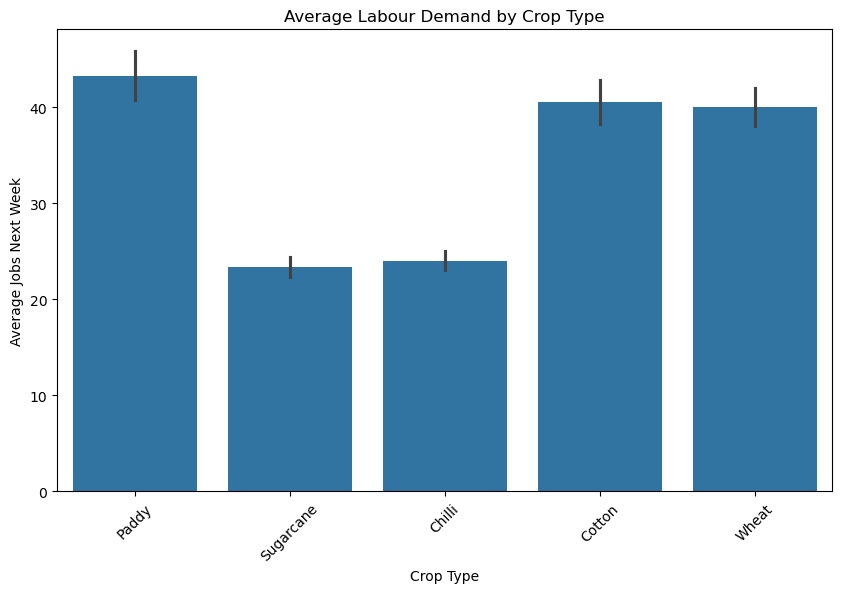

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x='Crop_Type',
    y='Total_Jobs_Next_Week',
    estimator='mean'
)

plt.title('Average Labour Demand by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Average Jobs Next Week')
plt.xticks(rotation=45)

plt.show()

## Rabi Season (Winter)
Major Crops: Wheat

## Kharif Season (Monsoon)
Major Crops: Rice (paddy), Cotton, Chilli

## Annual Crop :sugarcane

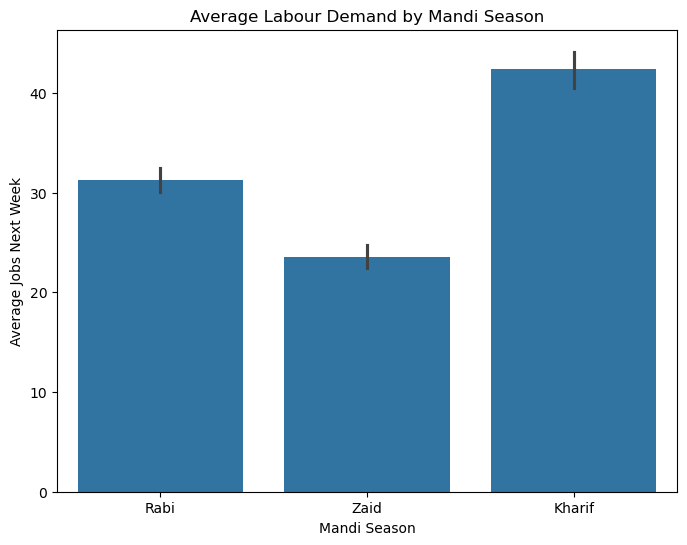

In [70]:

plt.figure(figsize=(8, 6))

sns.barplot(
    data=df,
    x='Mandi_Season',
    y='Total_Jobs_Next_Week',
    estimator='mean'
)

plt.title('Average Labour Demand by Mandi Season')
plt.xlabel('Mandi Season')
plt.ylabel('Average Jobs Next Week')

plt.show()

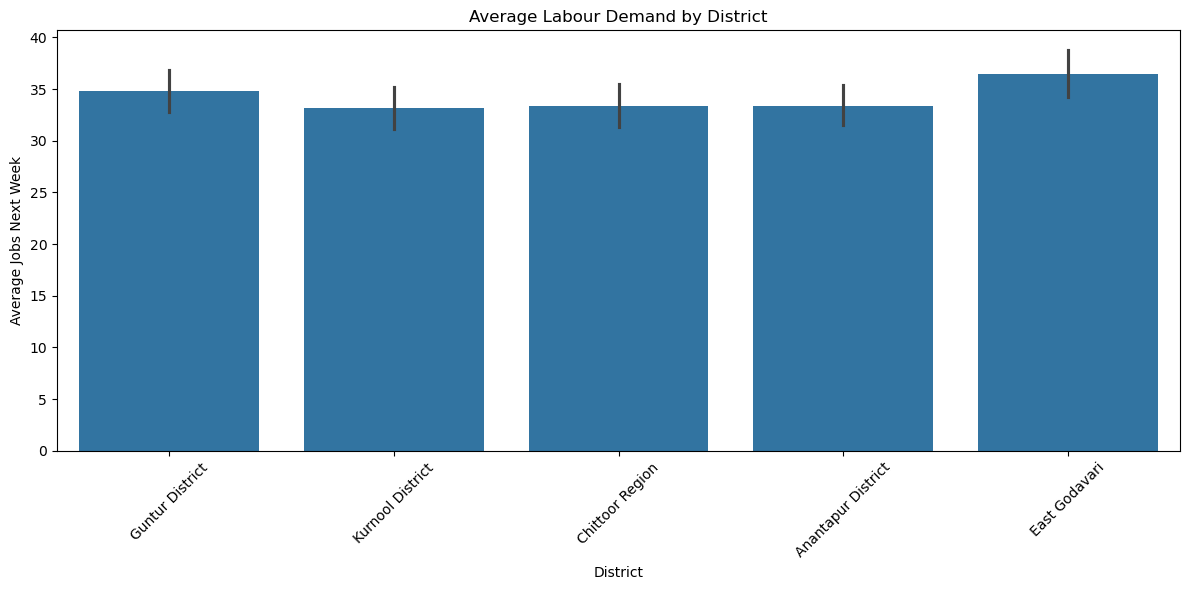

In [71]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x='Region_ID / District',
    y='Total_Jobs_Next_Week',
    estimator='mean'
)
plt.title('Average Labour Demand by District')
plt.xlabel('District')
plt.ylabel('Average Jobs Next Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

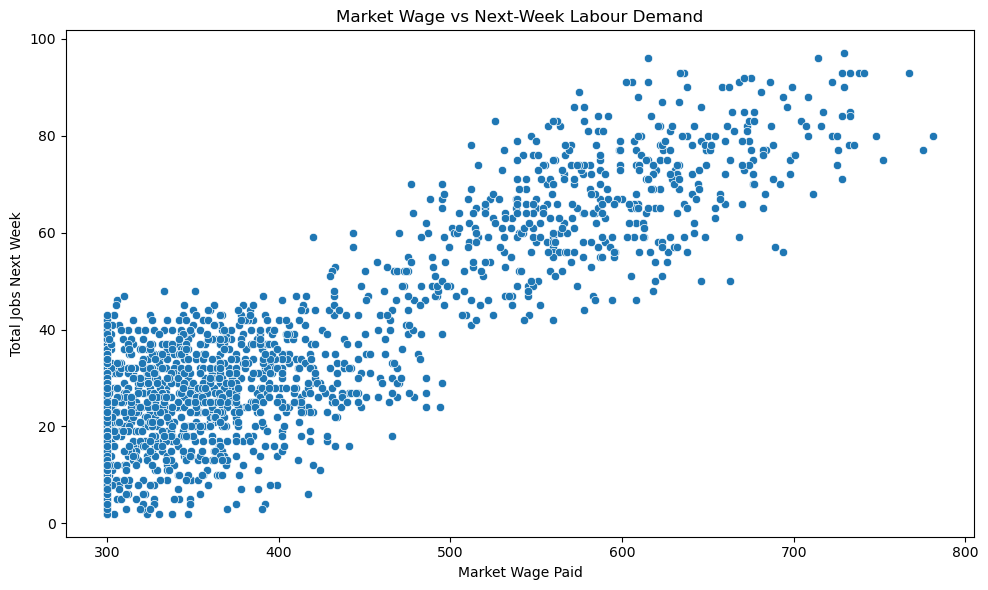

In [72]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Market_Wage_Paid',
    y='Total_Jobs_Next_Week'
)

plt.title('Market Wage vs Next-Week Labour Demand')
plt.xlabel('Market Wage Paid')
plt.ylabel('Total Jobs Next Week')

plt.tight_layout()
plt.show()

In [73]:
# 3. Separate Features (X) and Targets (Y)

X = df.drop(columns=['Market_Wage_Paid', 'Total_Jobs_Next_Week'])

y_wage = df['Market_Wage_Paid']

y_jobs = df['Total_Jobs_Next_Week']

# 4. One-Hot Encode all categorical ('object') text columns automatically
X_encoded = pd.get_dummies(X, columns=['Region_ID / District', 'Crop_Type', 'Weather_Condition'], drop_first=True)
print(f"Encoded feature count (Numbers only): {X_encoded.shape[1]}")


Encoded feature count (Numbers only): 15


In [74]:
X_encoded.head()

,Historical_Labour_Demanded,Historical_Labour_Supplied,Date,Mandi_Season,Region_ID / District_Chittoor Region,Region_ID / District_East Godavari,Region_ID / District_Guntur District,Region_ID / District_Kurnool District,Crop_Type_Cotton,Crop_Type_Paddy,Crop_Type_Sugarcane,Crop_Type_Wheat,Weather_Condition_Heavy Rain Alert,Weather_Condition_Moderate Rainfall,Weather_Condition_Sunny / Dry
0,58,93,2025-01-01,Rabi,False,False,True,False,False,True,False,False,True,False,False
1,58,83,2025-01-02,Rabi,False,False,False,True,False,False,True,False,False,True,False
2,30,75,2025-01-03,Rabi,False,False,True,False,False,False,False,False,False,False,True
3,22,86,2025-01-04,Rabi,True,False,False,False,True,False,False,False,False,False,True
4,21,88,2025-01-05,Rabi,False,False,True,False,False,True,False,False,False,True,False


## Prepare Date for the pipeline

 Date is currently:
datetime64[ns]

A regression model cannot directly use a datetime object, so we'll convert it to a numeric date value while keeping it as one feature

In [75]:
# Convert Date to a numeric day representation
X = X.copy()

X['Date'] = X['Date'].map(pd.Timestamp.toordinal)

print(X.dtypes)

Region_ID / District          object
Crop_Type                     object
Weather_Condition             object
Historical_Labour_Demanded     int64
Historical_Labour_Supplied     int64
Date                           int64
Mandi_Season                  object
dtype: object


## Train/Test Split + Preprocessing Pipeline

In [76]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Identify feature types
categorical_features = [
    'Mandi_Season',
    'Region_ID / District',
    'Crop_Type',
    'Weather_Condition'
]

numeric_features = [
    'Date',
    'Historical_Labour_Demanded',
    'Historical_Labour_Supplied'
]

X_train, X_test, y_wage_train, y_wage_test, y_jobs_train, y_jobs_test = train_test_split(
    X,
    y_wage,
    y_jobs,
    test_size=0.2,
    random_state=42
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                drop='first'
            ),
            categorical_features
        )
    ]
)

print("✓ Preprocessor created successfully")



✓ Preprocessor created successfully


In [77]:
df.describe()

,Historical_Labour_Demanded,Historical_Labour_Supplied,Market_Wage_Paid,Total_Jobs_Next_Week,Date
count,2000.000000,2000.000000,2000.000000,2000.000000,2000
mean,63.908000,82.902000,400.046500,34.234500,2025-12-05 20:24:00.000000256
min,20.000000,40.000000,300.000000,2.000000,2025-01-01 00:00:00
25%,36.000000,70.000000,300.000000,19.000000,2025-06-16 00:00:00
50%,53.000000,83.000000,351.000000,28.000000,2025-11-30 00:00:00
75%,85.000000,97.000000,467.000000,44.000000,2026-05-15 06:00:00
max,159.000000,114.000000,781.000000,97.000000,2026-12-31 00:00:00
std,36.915429,18.037324,118.684942,21.453056,NaN


Step 6 — Initialize and Train the 5 Models

Now we use MultiOutputRegressor.

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR

# Create the five models:
models = {
    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    ),

    "SVR": SVR()
}

Now create a pipeline for each model:

In [79]:
from sklearn.base import clone

In [80]:
trained_wage_models = {}
trained_jobs_models = {}

for name, model in models.items():

    # --------------------------------
    # MODEL 1: MARKET WAGE
    # --------------------------------

    wage_pipeline = Pipeline(
        steps=[
            ('preprocessor', clone(preprocessor)),
            ('model', clone(model))
        ]
    )

    wage_pipeline.fit(
        X_train,
        y_wage_train
    )

    trained_wage_models[name] = wage_pipeline


    # --------------------------------
    # MODEL 2: LABOUR DEMAND
    # --------------------------------

    jobs_pipeline = Pipeline(
        steps=[
            ('preprocessor', clone(preprocessor)),
            ('model', clone(model))
        ]
    )

    jobs_pipeline.fit(
        X_train,
        y_jobs_train
    )

    trained_jobs_models[name] = jobs_pipeline


    print(f"✓ {name} trained separately for both targets")

✓ Linear Regression trained separately for both targets
✓ Decision Tree trained separately for both targets
✓ Random Forest trained separately for both targets
✓ Gradient Boosting trained separately for both targets
✓ SVR trained separately for both targets


In [81]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
results = []

for name in models.keys():

    # -----------------------------
    # WAGE MODEL
    # -----------------------------
    wage_model = trained_wage_models[name]

    wage_pred = wage_model.predict(X_test)

    wage_r2 = r2_score(
        y_wage_test,
        wage_pred
    )

    wage_mae = mean_absolute_error(
        y_wage_test,
        wage_pred
    )

    wage_rmse = np.sqrt(
        mean_squared_error(
            y_wage_test,
            wage_pred
        )
    )


    # -----------------------------
    # JOB DEMAND MODEL
    # -----------------------------
    jobs_model = trained_jobs_models[name]

    jobs_pred = jobs_model.predict(X_test)

    jobs_r2 = r2_score(
        y_jobs_test,
        jobs_pred
    )

    jobs_mae = mean_absolute_error(
        y_jobs_test,
        jobs_pred
    )

    jobs_rmse = np.sqrt(
        mean_squared_error(
            y_jobs_test,
            jobs_pred
        )
    )


    results.append({
        'Model': name,

        'Wage R2': wage_r2,
        'Wage MAE': wage_mae,
        'Wage RMSE': wage_rmse,

        'Jobs R2': jobs_r2,
        'Jobs MAE': jobs_mae,
        'Jobs RMSE': jobs_rmse
    })


results_df = pd.DataFrame(results)

display(results_df)

,Model,Wage R2,Wage MAE,Wage RMSE,Jobs R2,Jobs MAE,Jobs RMSE
0,Linear Regression,0.970107,16.258834,20.953794,0.899745,6.103324,7.054113
1,Decision Tree,0.981651,11.297500,16.416379,0.796570,8.345000,10.048383
2,Random Forest,0.990270,8.423725,11.954580,0.887570,6.300500,7.470180
3,Gradient Boosting,0.989648,9.374822,12.330528,0.893117,6.253845,7.283545
4,SVR,0.749352,36.811987,60.674822,0.853602,7.165307,8.524269


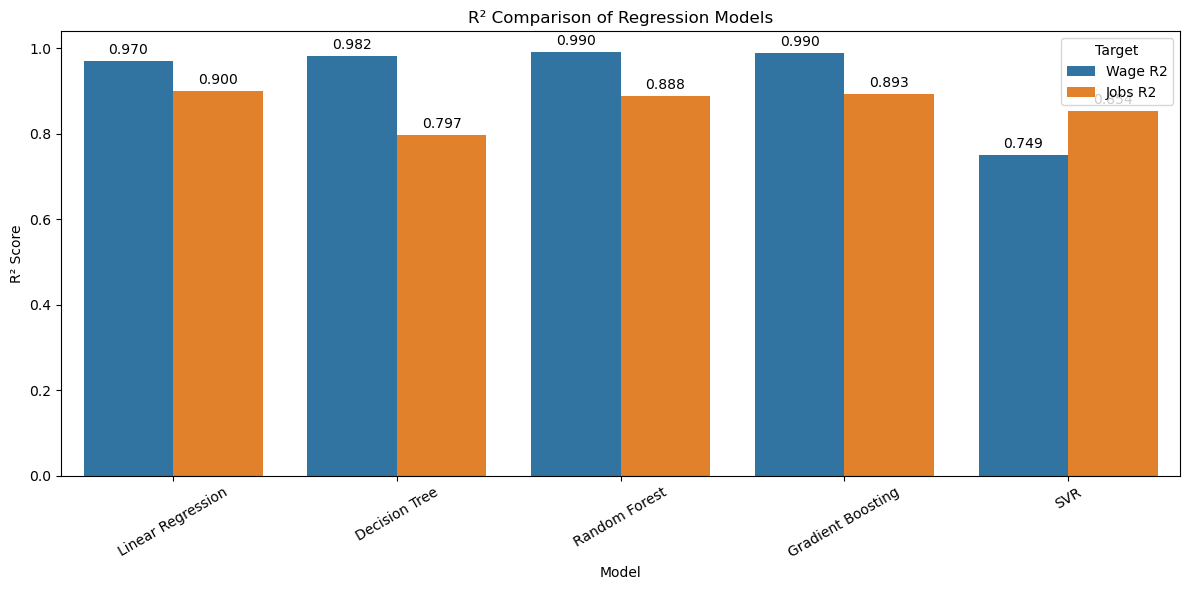

In [82]:
plt.figure(figsize=(12, 6))

comparison = results_df.melt(
    id_vars='Model',
    value_vars=['Wage R2', 'Jobs R2'],
    var_name='Target',
    value_name='R2'
)

ax = sns.barplot(
    data=comparison,
    x='Model',
    y='R2',
    hue='Target'
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3
    )

plt.title('R² Comparison of Regression Models')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.xticks(rotation=30)
plt.legend(title='Target')

plt.tight_layout()
plt.show()

## Get Gradient Boosting predictions

In [83]:
# Gradient Boosting model for Market Wage
wage_model = trained_wage_models["Gradient Boosting"]

# Gradient Boosting model for Labour Demand
jobs_model = trained_jobs_models["Gradient Boosting"]


# Predictions
wage_pred = wage_model.predict(X_test)

jobs_pred = jobs_model.predict(X_test)

##  Actual vs Predicted — Market Wage

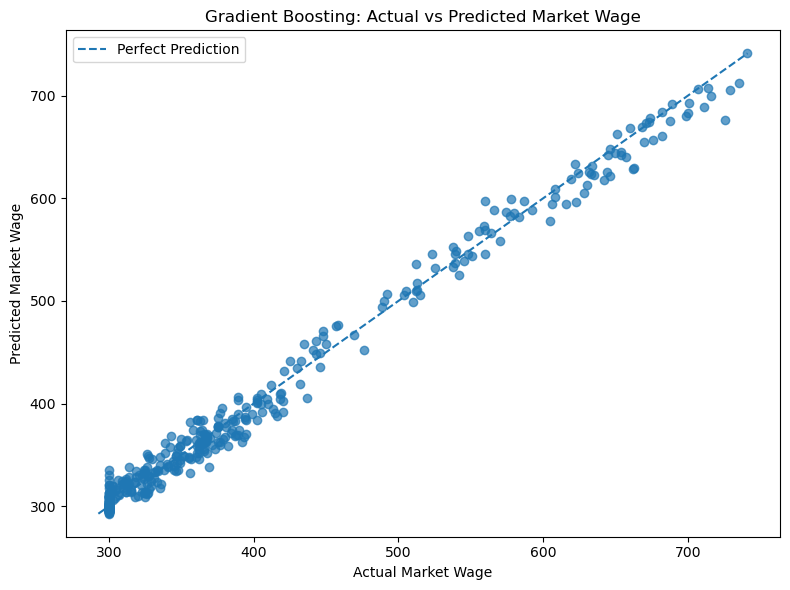

In [84]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_wage_test,
    wage_pred,
    alpha=0.7
)

min_value = min(
    y_wage_test.min(),
    wage_pred.min()
)

max_value = max(
    y_wage_test.max(),
    wage_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--',
    label='Perfect Prediction'
)

plt.title('Gradient Boosting: Actual vs Predicted Market Wage')
plt.xlabel('Actual Market Wage')
plt.ylabel('Predicted Market Wage')
plt.legend()

plt.tight_layout()
plt.show()

## Actual vs Predicted — Next-Week Jobs

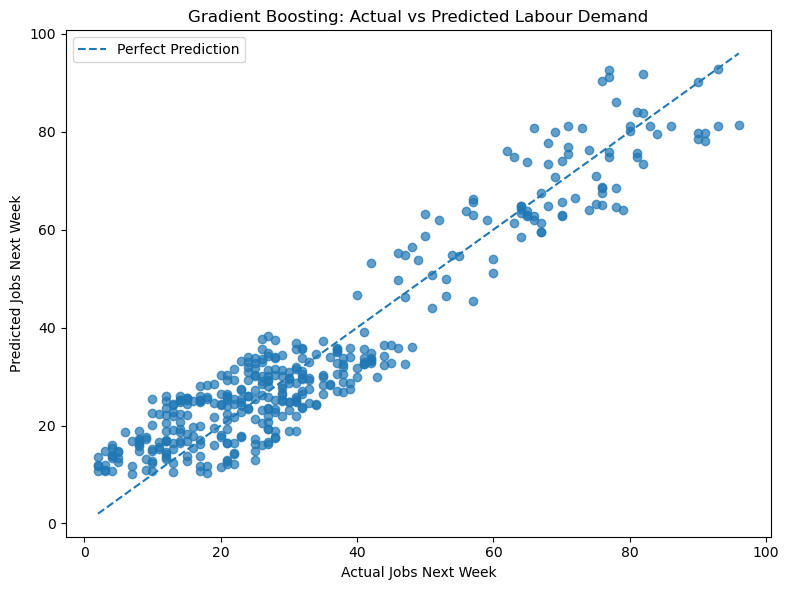

In [85]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_jobs_test,
    jobs_pred,
    alpha=0.7
)

min_value = min(
    y_jobs_test.min(),
    jobs_pred.min()
)

max_value = max(
    y_jobs_test.max(),
    jobs_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle='--',
    label='Perfect Prediction'
)

plt.title('Gradient Boosting: Actual vs Predicted Labour Demand')
plt.xlabel('Actual Jobs Next Week')
plt.ylabel('Predicted Jobs Next Week')
plt.legend()

plt.tight_layout()
plt.show()

Create a sample farmer input

In [86]:
# Sample new input
sample_input = pd.DataFrame({
    'Date': [pd.Timestamp('2026-10-05').toordinal()],
    'Mandi_Season': ['Rabi'],
    'Region_ID / District': ['Guntur District'],
    'Crop_Type': ['Paddy'],
    'Weather_Condition': ['Heavy Rain Alert'],
    'Historical_Labour_Demanded': [60],
    'Historical_Labour_Supplied': [45]
})

display(sample_input)

,Date,Mandi_Season,Region_ID / District,Crop_Type,Weather_Condition,Historical_Labour_Demanded,Historical_Labour_Supplied
0,739894,Rabi,Guntur District,Paddy,Heavy Rain Alert,60,45


Predict using Gradient Boosting

In [87]:
# Gradient Boosting Wage Model
wage_model = trained_wage_models["Gradient Boosting"]

# Gradient Boosting Labour Demand Model
jobs_model = trained_jobs_models["Gradient Boosting"]


# Predict Market Wage
predicted_wage = wage_model.predict(sample_input)[0]


# Predict Labour Demand
predicted_jobs = jobs_model.predict(sample_input)[0]


print("----- Gradient Boosting Prediction -----")
print(f"Predicted Market Wage: ₹{predicted_wage:.2f}")
print(f"Predicted Jobs Next Week: {predicted_jobs:.0f}")

----- Gradient Boosting Prediction -----
Predicted Market Wage: ₹481.34
Predicted Jobs Next Week: 34


In [88]:
import joblib
import os

# --------------------------------
# Select final trained models
# --------------------------------

wage_model = trained_wage_models["Gradient Boosting"]

jobs_model = trained_jobs_models["Gradient Boosting"]


# --------------------------------
# File paths
# --------------------------------

wage_model_path = "../../models/market_wage_model.pkl"

jobs_model_path = "../../models/labour_demand_model.pkl"


# --------------------------------
# Save Market Wage Model
# --------------------------------

joblib.dump(
    wage_model,
    wage_model_path
)

print("✓ Market Wage model saved successfully!")
print(f"Saved at: {wage_model_path}")


# --------------------------------
# Save Labour Demand Model
# --------------------------------

joblib.dump(
    jobs_model,
    jobs_model_path
)

print("✓ Labour Demand model saved successfully!")
print(f"Saved at: {jobs_model_path}")

✓ Market Wage model saved successfully!
Saved at: ../../models/market_wage_model.pkl
✓ Labour Demand model saved successfully!
Saved at: ../../models/labour_demand_model.pkl


In [89]:
import joblib

wage_model = joblib.load("../../models/market_wage_model.pkl")
jobs_model = joblib.load("../../models/labour_demand_model.pkl")

predicted_wage = wage_model.predict(sample_input)[0]
predicted_jobs = jobs_model.predict(sample_input)[0]

print(f"Predicted Market Wage: ₹{predicted_wage:.2f}")
print(f"Predicted Jobs Next Week: {predicted_jobs:.0f}")

Predicted Market Wage: ₹481.34
Predicted Jobs Next Week: 34
